<a href="https://colab.research.google.com/github/sylvia8181/RFM-Analysis/blob/main/finished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Title
## Second Title
- item 1
- item 2
- item 3
**abcde**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("RFM_Raw.csv")
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/01/01,JA1803995,A0620,411.400
1,2018/01/01,JA1805774,A1336,658.240
2,2018/01/01,JA1801197,A0786,1892.352
3,2018/01/02,JA1805224,A0937,411.400
4,2018/01/02,JA1802973,A1371,411.400


In [8]:
import pandas as pd

# 假設您的原始 DataFrame 為 df，欄位包含: Date, InvoNo, CustomerKey, Amount
# df = pd.DataFrame(...)

# 1. 確保 Date 欄位為 datetime 格式，以便進行日期運算
df['Date'] = pd.to_datetime(df['Date'])

# 2. 取得整個資料集中的最大日期作為基準日
max_date = df['Date'].max()

# 3. 透過 groupby 進行聚合計算
# F: 發票編號計數 (若每一筆交易對應一張發票，用 'count'；若要不重複發票數可改用 'nunique')
# M: 金額加總
# Customer: 客戶ID (CustomerKey)
rfm_df = df.groupby('CustomerKey').agg(
    F=('InvoNo', 'count'),
    M=('Amount', 'sum'),
    Customer_Max_Date=('Date', 'max') # 暫存每個客戶的最近交易日期
).reset_index()

# 重新命名 CustomerKey 欄位為 Customer
rfm_df = rfm_df.rename(columns={'CustomerKey': 'Customer'})

# 4. 計算 R：全域最大日期 - 該客戶的最大交易日期（轉換為天數）
rfm_df['R'] = (max_date - rfm_df['Customer_Max_Date']).dt.days

# 5. 移除暫存的日期欄位，並調整最終欄位順序為: Customer, F, M, R
rfm_df = rfm_df.drop(columns=['Customer_Max_Date'])
rfm_df = rfm_df[['Customer', 'F', 'M', 'R']]

print(rfm_df)

    Customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]


In [9]:
rfm_df.to_csv("RFM_Data.csv",index=False)

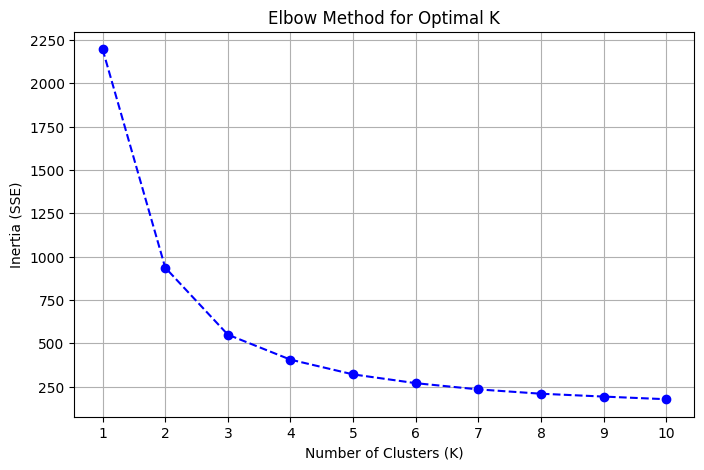

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 提取 RFM 特徵
rfm_features = rfm_df[['R', 'F', 'M']]

# 2. 特徵標準化
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# 3. 計算不同 K 值的 SSE
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

# 4. 繪製手肘圖 (Elbow Chart)
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [14]:
# 使用 K=4 執行 K-means 分群
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

# 顯示分群後的前 10 筆資料
display(rfm_df.head(10))

,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,0
1,A0351,6,17890.31200,16,1
2,A0352,14,46424.03852,14,0
3,A0353,14,27607.68636,24,0
4,A0354,6,9973.92064,31,1
5,A0355,8,20105.90008,29,1
6,A0356,10,15733.79076,85,1
7,A0357,20,58583.10320,24,0
8,A0363,4,8215.54050,8,1
9,A0365,5,13192.47600,92,1


In [15]:
# 統計每個分群的人數與 RFM 平均值
cluster_summary = rfm_df.groupby('Cluster').agg(
    Count=('Customer', 'count'),
    R_Mean=('R', 'mean'),
    F_Mean=('F', 'mean'),
    M_Mean=('M', 'mean')
).reset_index()

display(cluster_summary)

,Cluster,Count,R_Mean,F_Mean,M_Mean
0,0,226,17.725664,19.057522,44831.750987
1,1,315,45.374603,5.612698,13480.138373
2,2,116,15.103448,26.146552,76760.157041
3,3,75,183.653333,3.640000,8586.611298


In [16]:
# 1. 將 rfm_df 的 Cluster 欄位與原始 df 進行對照合併
# 原始 df 的客戶 ID 為 'CustomerKey'，rfm_df 為 'Customer'
df = df.merge(rfm_df[['Customer', 'Cluster']], left_on='CustomerKey', right_on='Customer', how='left')

# 2. 移除重複的 'Customer' 欄位（保留原始的 'CustomerKey' 與新加入的 'Cluster'）
if 'Customer' in df.columns:
    df = df.drop(columns=['Customer'])

# 顯示合併後的前 10 筆原始明細資料
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster
0,2018-01-01,JA1803995,A0620,411.40000,3
1,2018-01-01,JA1805774,A1336,658.24000,1
2,2018-01-01,JA1801197,A0786,1892.35200,1
3,2018-01-02,JA1805224,A0937,411.40000,0
4,2018-01-02,JA1802973,A1371,411.40000,1
5,2018-01-02,JA1808698,A0983,946.17600,1
6,2018-01-02,JA1800463,A0887,822.80000,2
7,2018-01-02,JA1802933,A0764,2100.47904,2
8,2018-01-02,JA1807201,A0667,2843.07264,1
9,2018-01-02,JA1803169,A1014,2843.07264,0


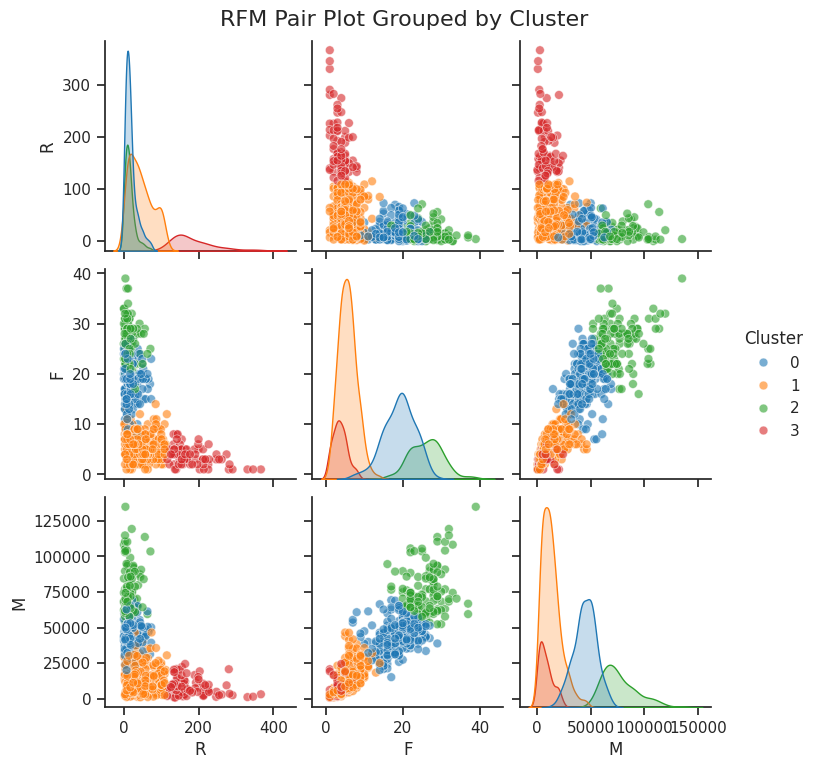

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 由於 df 是交易明細，我們需要先將每個客戶的 RFM 數值與其對應的 Cluster 整理出來
# 這裡我們可以直接使用已經計算好且含有 Cluster 欄位的 rfm_df 來繪製 Pair Plot，這能更準確地呈現客戶層級的分群關係。

# 設定繪圖風格與字體
sns.set_theme(style="ticks")

# 繪製 Pair Plot，以 Cluster 作為分類顏色 (hue)
g = sns.pairplot(
    rfm_df,
    vars=['R', 'F', 'M'],
    hue='Cluster',
    palette='tab10',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('RFM Pair Plot Grouped by Cluster', y=1.02, fontsize=16)
plt.show()

In [18]:
# 定義 Cluster 與群組名稱的對照字典
cluster_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位並套用對照
df['Group'] = df['Cluster'].map(cluster_mapping)

# 顯示新增欄位後的前 10 筆資料以進行確認
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster,Group
0,2018-01-01,JA1803995,A0620,411.40000,3,Medium
1,2018-01-01,JA1805774,A1336,658.24000,1,High
2,2018-01-01,JA1801197,A0786,1892.35200,1,High
3,2018-01-02,JA1805224,A0937,411.40000,0,Missing
4,2018-01-02,JA1802973,A1371,411.40000,1,High
5,2018-01-02,JA1808698,A0983,946.17600,1,High
6,2018-01-02,JA1800463,A0887,822.80000,2,Low
7,2018-01-02,JA1802933,A0764,2100.47904,2,Low
8,2018-01-02,JA1807201,A0667,2843.07264,1,High
9,2018-01-02,JA1803169,A1014,2843.07264,0,Missing


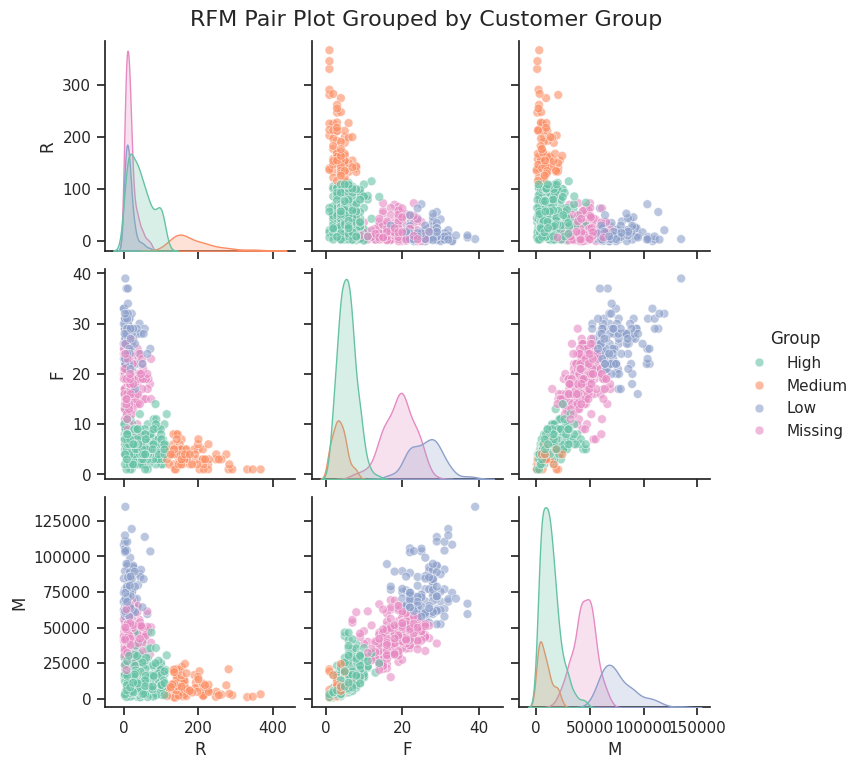

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 先將 Group 標籤也對應到客群層級的 rfm_df 中，以便繪製準確的客戶分佈圖
rfm_df['Group'] = rfm_df['Cluster'].map(cluster_mapping)

# 2. 設定繪圖風格
sns.set_theme(style="ticks")

# 3. 繪製 Pair Plot，改以 Group 作為分類顏色 (hue)
# 指定 hue_order 讓圖例順序更符合直覺
g = sns.pairplot(
    rfm_df,
    vars=['R', 'F', 'M'],
    hue='Group',
    hue_order=['High', 'Medium', 'Low', 'Missing'],
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('RFM Pair Plot Grouped by Customer Group', y=1.02, fontsize=16)
plt.show()

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# 1. 設定繪圖風格
sns.set_theme(style="ticks")

# 2. 繪製 Pair Plot（設定透明背景）
g = sns.pairplot(
    rfm_df,
    vars=['R', 'F', 'M'],
    hue='Group',
    hue_order=['High', 'Medium', 'Low', 'Missing'],
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40}
)

g.fig.suptitle('RFM Pair Plot Grouped by Customer Group', y=1.02, fontsize=16)

# 3. 儲存圖檔為透明背景 PNG 格式
output_filename = 'RFM_Pairplot.png'
# 使用 transparent=True 來確保存出的圖檔背景是透明的
plt.savefig(output_filename, dpi=300, bbox_inches='tight', transparent=True)
plt.close()

# 4. 觸發瀏覽器下載該檔案
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
from google.colab import files

# 將 df 匯出為 CSV 檔案，不保留 Pandas 預設索引 (index)
output_csv = 'RFM_result.csv'
df.to_csv(output_csv, index=False, encoding='utf-8-sig')

# 觸發瀏覽器下載
files.download(output_csv)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>